In [ ]:
import pandas as pd

sessions = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/ML интенсив 12-18.08.2026/Lesson 1/callcenter/sessions.parquet').sort_values('date_time')

train = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/ML интенсив 12-18.08.2026/Lesson 1/callcenter/train.parquet')
test = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/ML интенсив 12-18.08.2026/Lesson 1/callcenter/test.parquet')

print('train shape:', train.shape)
print('test shape:', test.shape)
print('sessions shape:', sessions.shape)



train shape: (104595, 6)
test shape: (17196, 5)
sessions shape: (3334243, 6)


In [ ]:
train.head(3)

,order_id,create_time,good_id,price,sessionkey_id,is_callcenter
0,1269921,1975-12-26 09:30:08,9896348,753,123777004,1
1,1270034,1975-12-26 10:28:57,9896348,753,123781654,0
2,1268272,1975-12-25 11:24:28,9896348,753,123591002,1


In [ ]:
test.head(3)

,order_id,create_time,good_id,price,sessionkey_id
0,1350922,1976-02-05 15:08:37,9896348,1143,132744630
1,1354989,1976-02-07 15:26:00,69445048,1707,133161905
2,1352637,1976-02-06 11:43:58,70607886,576,132792626


In [ ]:
sessions.head(10)

,sessionkey_id,date_time,page_type,pageview_number,pageview_duration_sec,good_id
2268917,109996122,1975-10-17 13:42:56.953,2,1,11.0,None
2268918,109996122,1975-10-17 13:43:07.510,2,2,22.0,None
2268919,109996122,1975-10-17 13:43:29.860,2,3,25.0,None
2269206,109996122,1975-10-17 13:43:54.757,2,4,9.0,None
2267445,109996122,1975-10-17 13:44:03.803,2,5,11.0,None
2268626,109996122,1975-10-17 13:44:14.300,2,6,12.0,None
2267446,109996122,1975-10-17 13:44:26.633,2,7,NaN,None
2268627,110019268,1975-10-17 15:25:56.300,7,1,122.0,None
2268628,110019268,1975-10-17 15:27:58.257,1,2,43.0,22312252
2269207,110019268,1975-10-17 15:28:41.860,7,3,NaN,None


Переведем даты в объект datetime64

In [ ]:
train.create_time = pd.to_datetime(train.create_time)
test.create_time = pd.to_datetime(test.create_time)
sessions.date_time = pd.to_datetime(sessions.date_time)
train.create_time

,create_time
0,1975-12-26 09:30:08
1,1975-12-26 10:28:57
2,1975-12-25 11:24:28
3,1975-12-26 14:16:06
4,1975-12-26 18:21:47
...,...
104590,1975-12-16 12:11:32
104591,1975-11-08 11:29:50
104592,1975-11-12 09:14:35
104593,1975-11-10 17:28:07


In [ ]:
%%time

session_aggregates = (
    sessions
    .sort_values('date_time')
    .groupby('sessionkey_id')
    .agg(
        date_time_min=pd.NamedAgg(column='date_time', aggfunc=lambda x: x.iloc[0]),
        date_time_max=pd.NamedAgg(column='date_time', aggfunc=lambda x: x.iloc[-1]),
        ends_with_nan_sec=pd.NamedAgg(column='pageview_duration_sec', aggfunc=lambda x: pd.isna(x.iloc[-1])),
        session_pages_cnt=pd.NamedAgg(column='pageview_duration_sec', aggfunc=lambda x: x.shape[0]),
        sec_on_last_page=pd.NamedAgg(column='pageview_duration_sec', aggfunc=lambda x: x.iloc[-1])
    )
)
session_aggregates

CPU times: user 49.3 s, sys: 335 ms, total: 49.7 s
Wall time: 51.8 s


,date_time_min,date_time_max,ends_with_nan_sec,session_pages_cnt,sec_on_last_page
sessionkey_id,,,,,
109996122,1975-10-17 13:42:56.953,1975-10-17 13:44:26.633,True,7,NaN
110019268,1975-10-17 15:25:56.300,1975-10-17 15:28:41.860,True,3,NaN
110020180,1975-10-17 15:29:52.147,1975-10-17 15:29:52.147,True,1,NaN
110040418,1975-10-17 17:05:41.530,1975-10-17 17:15:33.020,True,11,NaN
110044482,1975-10-17 17:27:55.297,1975-10-17 17:27:55.297,True,1,NaN
...,...,...,...,...,...
134626779,1976-02-16 20:47:13.283,1976-02-16 20:47:13.283,False,1,22.0
134627402,1976-02-16 20:50:10.233,1976-02-16 20:55:09.017,True,7,NaN
134628420,1976-02-16 20:54:40.853,1976-02-16 20:59:14.477,True,5,NaN


In [ ]:
session_aggregates['delta_time'] = session_aggregates['date_time_max'] - session_aggregates['date_time_min']
session_aggregates['delta_time'] = session_aggregates['delta_time'].dt.total_seconds()

session_aggregates

,date_time_min,date_time_max,ends_with_nan_sec,session_pages_cnt,sec_on_last_page,delta_time
sessionkey_id,,,,,,
109996122,1975-10-17 13:42:56.953,1975-10-17 13:44:26.633,True,7,NaN,89.680
110019268,1975-10-17 15:25:56.300,1975-10-17 15:28:41.860,True,3,NaN,165.560
110020180,1975-10-17 15:29:52.147,1975-10-17 15:29:52.147,True,1,NaN,0.000
110040418,1975-10-17 17:05:41.530,1975-10-17 17:15:33.020,True,11,NaN,591.490
110044482,1975-10-17 17:27:55.297,1975-10-17 17:27:55.297,True,1,NaN,0.000
...,...,...,...,...,...,...
134626779,1976-02-16 20:47:13.283,1976-02-16 20:47:13.283,False,1,22.0,0.000
134627402,1976-02-16 20:50:10.233,1976-02-16 20:55:09.017,True,7,NaN,298.784
134628420,1976-02-16 20:54:40.853,1976-02-16 20:59:14.477,True,5,NaN,273.624


Посчитаем сумму просмотра всех страниц в секундах по каждой сессии и добавим новый столбец к session_agregates

In [ ]:

session_aggregates['total_pageview_duration_sec'] = (
    sessions
    .groupby('sessionkey_id')['pageview_duration_sec'].sum()
)
session_aggregates

,date_time_min,date_time_max,ends_with_nan_sec,session_pages_cnt,sec_on_last_page,delta_time,total_pageview_duration_sec
sessionkey_id,,,,,,,
109996122,1975-10-17 13:42:56.953,1975-10-17 13:44:26.633,True,7,NaN,89.680,90.0
110019268,1975-10-17 15:25:56.300,1975-10-17 15:28:41.860,True,3,NaN,165.560,165.0
110020180,1975-10-17 15:29:52.147,1975-10-17 15:29:52.147,True,1,NaN,0.000,0.0
110040418,1975-10-17 17:05:41.530,1975-10-17 17:15:33.020,True,11,NaN,591.490,545.0
110044482,1975-10-17 17:27:55.297,1975-10-17 17:27:55.297,True,1,NaN,0.000,0.0
...,...,...,...,...,...,...,...
134626779,1976-02-16 20:47:13.283,1976-02-16 20:47:13.283,False,1,22.0,0.000,22.0
134627402,1976-02-16 20:50:10.233,1976-02-16 20:55:09.017,True,7,NaN,298.784,244.0
134628420,1976-02-16 20:54:40.853,1976-02-16 20:59:14.477,True,5,NaN,273.624,93.0


In [ ]:
session_aggregates['gap'] = session_aggregates['total_pageview_duration_sec'] - session_aggregates['delta_time']
session_aggregates

,date_time_min,date_time_max,ends_with_nan_sec,session_pages_cnt,sec_on_last_page,delta_time,total_pageview_duration_sec,gap
sessionkey_id,,,,,,,,
109996122,1975-10-17 13:42:56.953,1975-10-17 13:44:26.633,True,7,NaN,89.680,90.0,0.320
110019268,1975-10-17 15:25:56.300,1975-10-17 15:28:41.860,True,3,NaN,165.560,165.0,-0.560
110020180,1975-10-17 15:29:52.147,1975-10-17 15:29:52.147,True,1,NaN,0.000,0.0,0.000
110040418,1975-10-17 17:05:41.530,1975-10-17 17:15:33.020,True,11,NaN,591.490,545.0,-46.490
110044482,1975-10-17 17:27:55.297,1975-10-17 17:27:55.297,True,1,NaN,0.000,0.0,0.000
...,...,...,...,...,...,...,...,...
134626779,1976-02-16 20:47:13.283,1976-02-16 20:47:13.283,False,1,22.0,0.000,22.0,22.000
134627402,1976-02-16 20:50:10.233,1976-02-16 20:55:09.017,True,7,NaN,298.784,244.0,-54.784
134628420,1976-02-16 20:54:40.853,1976-02-16 20:59:14.477,True,5,NaN,273.624,93.0,-180.624


Глазами вижу, что время на последней странице **sec_on_last_page**
- не учитывается в длительность сессии **delta_time**
- учитывается только в сумме просмотра каждой страницы **total_pageview_duration_sec**,
то есть сумма просмотра
1. **total_pageview_duration_sec** (для всех **sec_on_last_page** != NaN) всегда(?) > **delta_time**
2. **total_pageview_duration_sec** - **delta_time** = **sec_on_last_page**
# Откуда появляются NaN?
гипотеза: если **total_pageview_duration_sec** (для всех **sec_on_last_page** != NaN или **ends_with_nan_sec** == False) < **delta_time**
ожидание: 100% для столбца **session_aggregates['total_pageview_duration > delta_time']** при проверке total>delta по маске ends_with_nan == False


In [ ]:
session_aggregates['total_pageview_duration > delta_time'] = session_aggregates['total_pageview_duration_sec'] > session_aggregates['delta_time']
print(f'Всего {session_aggregates['total_pageview_duration > delta_time'].value_counts()}')
print(f' Кончается не на NaN {session_aggregates.query('ends_with_nan_sec == False')['total_pageview_duration > delta_time'].value_counts()}')

print(f'Кончается на NaN {session_aggregates.query('ends_with_nan_sec == True')['total_pageview_duration > delta_time'].value_counts()}')

Всего total_pageview_duration > delta_time
False    234094
True      94336
Name: count, dtype: int64
 Кончается не на NaN total_pageview_duration > delta_time
True     21238
False    15512
Name: count, dtype: int64
Кончается на NaN total_pageview_duration > delta_time
False    218582
True      73098
Name: count, dtype: int64


**Вывод: Гипотеза не подтвердилась**

Появление NaN не связано с закрытием сессии раньше суммарного количества времени проведенного на страницах

**Гипотеза: может сессии начинают заканчиваться NaN-ом после просмотра определенного количества страниц**

Распределение сколько страниц обычно просмотрено, если сессия кончается не наном

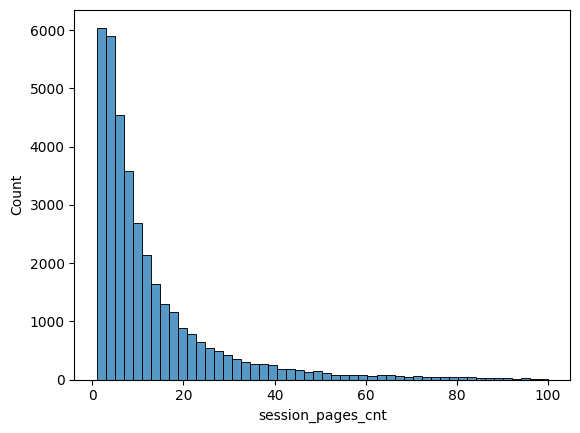

In [ ]:
session_aggregates.query('ends_with_nan_sec == False and total_pageview_duration_sec != 0').session_pages_cnt.value_counts()
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(
    session_aggregates.query('ends_with_nan_sec == False and total_pageview_duration_sec != 0').session_pages_cnt, bins=50, binrange=(1, 100)
)
plt.show()

Распределение сколько страниц обычно просмотрено, если сессия кончается наном

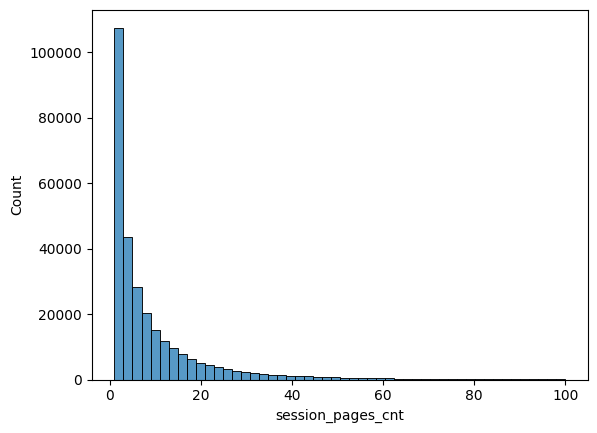

In [ ]:
sns.histplot(
    session_aggregates.query('ends_with_nan_sec == True').session_pages_cnt, bins=50, binrange=(1, 100)
)
plt.show()

**Вывод: Гипотеза не подтвердилась**
количество просмотренных страниц не влияет на то, окажется ли конечная страница с просмотром NaN

**Гипотеза: Распределение кол-ва страниц выглядят одинаково для сценариев оканчивающихся на NaN и на не NaN.**
Распределения выглядят похожими по форме, наложим графики а потом посмотрим на их нормированные версии

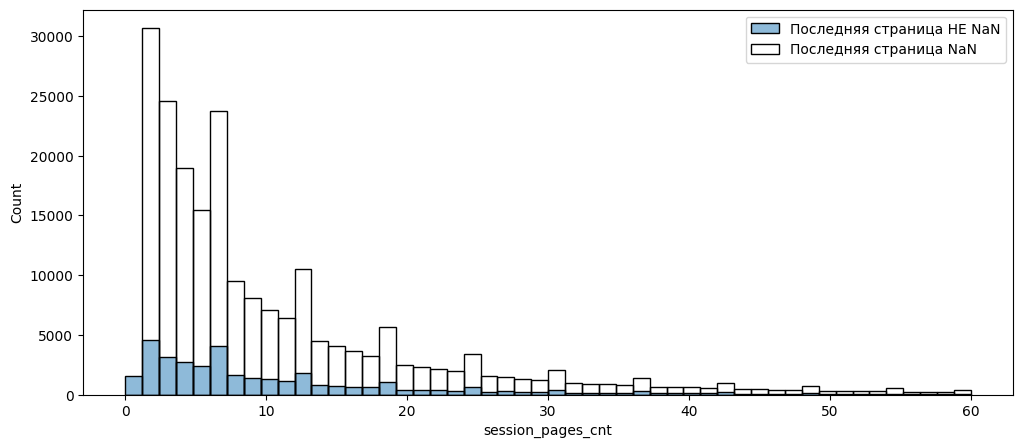

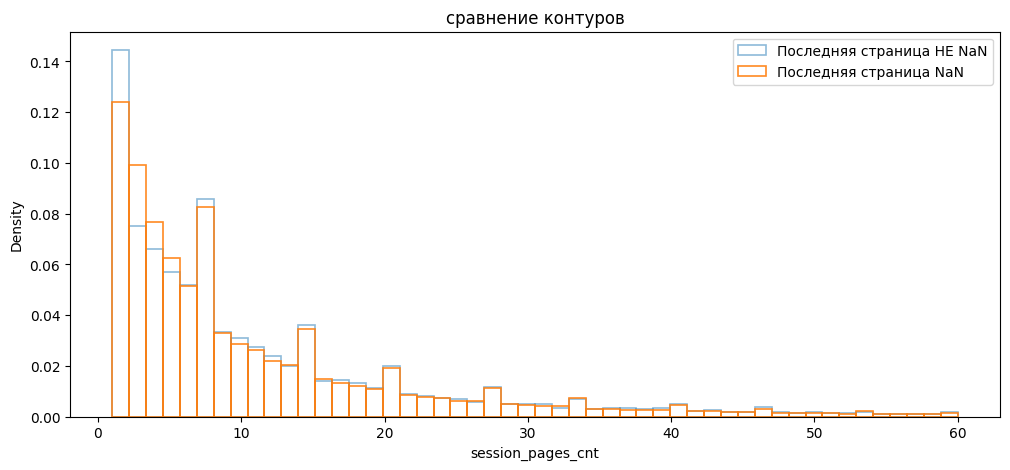

In [ ]:
plt.figure(figsize=(12, 5))

sns.histplot(
    session_aggregates.query('ends_with_nan_sec == False and total_pageview_duration_sec != 0').session_pages_cnt,
    bins=50,
    binrange=(0, 60),
    label = 'Последняя страница НЕ NaN',
    alpha = 0.5
)

sns.histplot(
    session_aggregates.query('ends_with_nan_sec == True and total_pageview_duration_sec != 0').session_pages_cnt,
    bins=50,
    binrange=(0, 60),
    label = 'Последняя страница NaN',
    alpha = 0
)
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))

sns.histplot(
    session_aggregates.query('ends_with_nan_sec == False and total_pageview_duration_sec != 0').session_pages_cnt,
    bins=50,
    binrange=(1, 60),
    label = 'Последняя страница НЕ NaN',
    alpha = 0.5,
    stat='density',
    #element='step',
    fill=False
)

sns.histplot(
    session_aggregates.query('ends_with_nan_sec == True and total_pageview_duration_sec != 0').session_pages_cnt,
    bins=50,
    binrange=(1, 60),
    label = 'Последняя страница NaN',
    alpha = 0.9,
    stat='density',
    #element='step',
    fill=False
)
plt.title('сравнение контуров')
plt.legend()
plt.show()

**Вывод: Гипотеза частично подтвердилась, особенно для кол-ва страниц > 20**

Видим, что форма распределений почти не зависит от кол-ва страниц, а зависит от какого-то другого параметра, который влияет на процентное соотношение NaN сценариев к не NaN. **Т.е есть что-то, что для NaN сценариев ПОСТОЯННО во много раз больше, чем для не NaN**

In [ ]:
print(train['sessionkey_id'].nunique())
print(train.shape[0])

96803
104595


т.е id повторяются, следовательно лучше присоединять session_aggregates где 1 id соответствует 1 строка, а не наоборот

In [ ]:
train = train.merge(session_aggregates, on='sessionkey_id', how='left')

In [ ]:
train['order_BEFORE_session'] = train['create_time'] < train['date_time_min']
train['order_DURING_session'] = (train['create_time'] > train['date_time_min']) & (train['create_time'] < train['date_time_max'])
train['order_AFTER_session'] = train['create_time'] > train['date_time_max']
train = train.drop(columns=['gap'])
train


,order_id,create_time,good_id,price,sessionkey_id,is_callcenter,date_time_min,date_time_max,ends_with_nan_sec,session_pages_cnt,sec_on_last_page,delta_time,total_pageview_duration_sec,total_pageview_duration > delta_time,order_BEFORE_session,order_DURING_session,order_AFTER_session
0,1269921,1975-12-26 09:30:08,9896348,753,123777004,1,1975-12-26 09:21:03.393,1975-12-26 09:21:03.393,True,1.0,NaN,0.000,0.0,False,False,False,True
1,1270034,1975-12-26 10:28:57,9896348,753,123781654,0,1975-12-26 09:50:26.857,1975-12-26 11:01:03.407,True,28.0,NaN,4236.550,3831.0,False,False,True,False
2,1268272,1975-12-25 11:24:28,9896348,753,123591002,1,1975-12-25 11:17:02.940,1975-12-25 11:23:12.517,True,7.0,NaN,369.577,370.0,True,False,False,True
3,1270544,1975-12-26 14:16:06,9896348,753,123832302,1,1975-12-26 13:57:51.157,1975-12-26 14:29:57.153,True,6.0,NaN,1925.996,1926.0,True,False,True,False
4,1270970,1975-12-26 18:21:47,9896348,753,123881603,0,1975-12-26 18:10:27.970,1975-12-26 18:17:54.257,False,6.0,9.0,446.287,94.0,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104590,1250981,1975-12-16 12:11:32,68657110,1497,121795335,1,1975-12-16 12:04:02.273,1975-12-16 12:56:06.990,True,9.0,NaN,3124.717,3109.0,False,False,True,False
104591,1173775,1975-11-08 11:29:50,60391507,1354,114277105,1,1975-11-07 23:37:34.260,1975-11-07 23:55:00.773,True,10.0,NaN,1046.513,610.0,False,False,False,True
104592,1180920,1975-11-12 09:14:35,66971400,1452,114972131,0,1975-11-12 08:37:30.500,1975-11-12 09:15:26.047,False,39.0,8.0,2275.547,1602.0,False,False,True,False
104593,1177882,1975-11-10 17:28:07,60391498,1433,114672813,1,1975-11-10 17:00:21.517,1975-11-10 17:23:02.973,True,9.0,NaN,1361.456,1361.0,False,False,False,True


In [ ]:
train.query('ends_with_nan_sec == True').order_BEFORE_session.value_counts()

,count
order_BEFORE_session,
False,83386
True,39


In [ ]:
train.query('ends_with_nan_sec == True').order_DURING_session.value_counts()

,count
order_DURING_session,
False,43335
True,40090


In [ ]:
train.query('ends_with_nan_sec == False').order_AFTER_session.value_counts()

,count
order_AFTER_session,
True,18103
False,2443


In [ ]:
print(train.order_BEFORE_session.value_counts())
print(train.order_DURING_session.value_counts())
print(train.order_AFTER_session.value_counts())

order_BEFORE_session
False    104553
True         42
Name: count, dtype: int64
order_DURING_session
False    62065
True     42530
Name: count, dtype: int64
order_AFTER_session
True     61399
False    43196
Name: count, dtype: int64


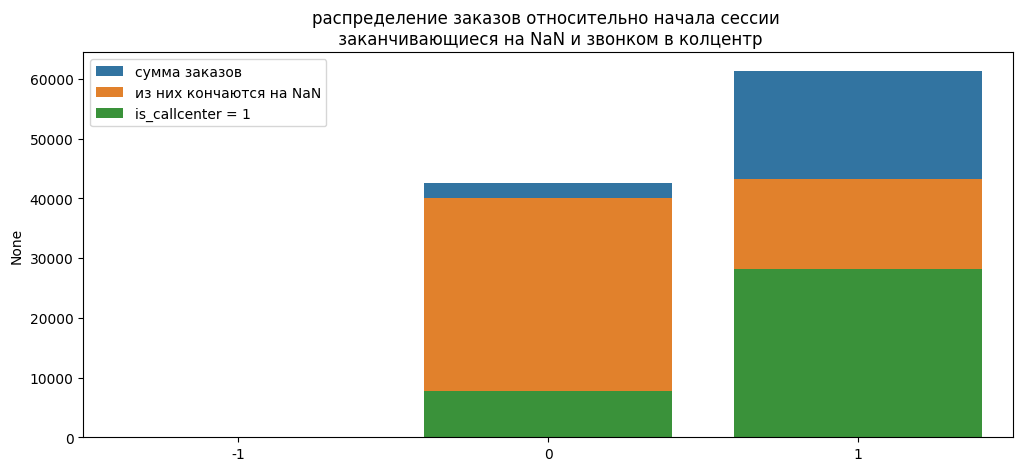

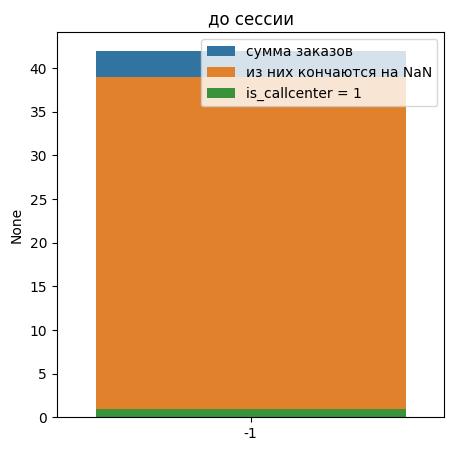

                period  total_orders  total_NaN  total_callcenter = 1  \
0  before_session (-1)            42         39                     1   
1    during_session(0)         42530      40090                  7750   
2     after_session(1)         61399      43296                 28131   

   NaN to total_orders %  is_callcenter1 to NaN %  \
0               0.928571                 0.025641   
1               0.942629                 0.193315   
2               0.705158                 0.649737   

   is_callcenter to total_orders  
0                       0.023810  
1                       0.182224  
2                       0.458167  


In [ ]:
plt.figure(figsize=(12, 5))

counts = [
    train['order_BEFORE_session'].sum(),
    train['order_DURING_session'].sum(),
    train['order_AFTER_session'].sum()
]
counts = pd.Series(counts)
sns.barplot(x=[-1, 0, 1], y=counts, label = 'сумма заказов')

counts1 = [
    train.query('ends_with_nan_sec == True')['order_BEFORE_session'].sum(),
    train.query('ends_with_nan_sec == True')['order_DURING_session'].sum(),
    train.query('ends_with_nan_sec == True')['order_AFTER_session'].sum()
]
counts1 = pd.Series(counts1)
sns.barplot(x=[-1, 0, 1], y=counts1, label = 'из них кончаются на NaN' )

counts2 = [
    train.query('ends_with_nan_sec == True and is_callcenter == 1')['order_BEFORE_session'].sum(),
    train.query('ends_with_nan_sec == True and is_callcenter == 1')['order_DURING_session'].sum(),
    train.query('ends_with_nan_sec == True and is_callcenter == 1')['order_AFTER_session'].sum()
]
counts2 = pd.Series(counts2)
sns.barplot(x=[-1, 0, 1], y=counts2, label = 'is_callcenter = 1' )

plt.title('распределение заказов относительно начала сессии \n заканчивающиеся на NaN и звонком в колцентр')
plt.legend()
plt.show()


plt.figure(figsize=(5, 5))
counts_before = [
    train['order_BEFORE_session'].sum()
]
counts_before = pd.Series(counts_before)
sns.barplot(x=[-1], y=counts_before, label = 'сумма заказов')

counts1_before = [
    train.query('ends_with_nan_sec == True')['order_BEFORE_session'].sum()
]
counts1_before = pd.Series(counts1_before)
sns.barplot(x=[-1], y=counts1_before, label = 'из них кончаются на NaN' )

counts2_before = [
    train.query('ends_with_nan_sec == True and is_callcenter == 1')['order_BEFORE_session'].sum()
]
counts2_before = pd.Series(counts2_before)
sns.barplot(x=[-1], y=counts2_before, label = 'is_callcenter = 1' )

plt.title('до сессии')
plt.legend()
plt.show()

counts3 = counts1 / counts
counts4 = counts2 / counts1
counts5 = counts2 / counts

statistic_for_each_period = pd.DataFrame({
    'period': ['before_session (-1)', 'during_session(0)', 'after_session(1)'],
    'total_orders': counts,
    'total_NaN': counts1,
    'total_callcenter = 1': counts2,
    'NaN to total_orders %': counts3,
    'is_callcenter1 to NaN %': counts4,
    'is_callcenter to total_orders': counts5
})
print(statistic_for_each_period)

In [ ]:
statistic_for_each_period

,period,total_orders,total_NaN,total_callcenter = 1,NaN to total_orders %,is_callcenter1 to NaN %,is_callcenter to total_orders
0,before_session (-1),42,39,1,0.928571,0.025641,0.023810
1,during_session(0),42530,40090,7750,0.942629,0.193315,0.182224
2,after_session(1),61399,43296,28131,0.705158,0.649737,0.458167


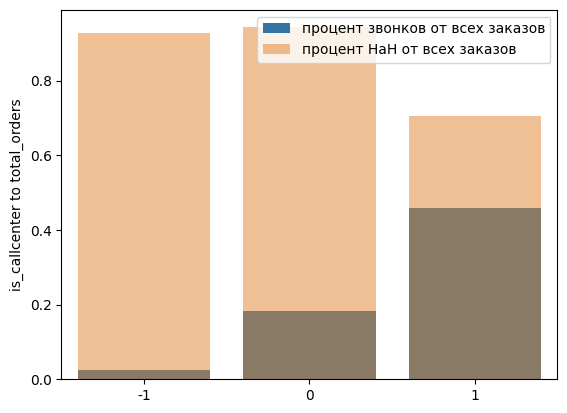

In [ ]:
#sns.barplot(data=statistic_for_each_period, x=[-1, 0, 1], y='total_orders')
#sns.barplot(data=statistic_for_each_period, x=[-1, 0, 1], y='total_callcenter = 1')
sns.barplot(data=statistic_for_each_period, x=[-1, 0, 1], y='is_callcenter to total_orders', label = 'процент звонков от всех заказов')
sns.barplot(data=statistic_for_each_period, x=[-1, 0, 1], y='NaN to total_orders %', label = 'процент НаН от всех заказов', alpha = 0.5)
plt.legend()
plt.show()

**Вывод:** процент звонков увеличивается после сессии, в то время как NaN уменьшаются.
Но NaN до сесси и во время составляют 90% от всех заказов

Посмотрим на разнообразие товаров good_id, может получится связать причину звонков или NaN окончаний сессий с товарами

In [ ]:
print(train.good_id.value_counts())
print(train.query('ends_with_nan_sec == True').good_id.value_counts())
print(train.query('is_callcenter == 1').good_id.value_counts())

good_id
66921494    260
59028238    184
59028240    178
59028239    177
59028310    136
           ... 
57998993      1
72488252      1
31463659      1
74298425      1
66917588      1
Name: count, Length: 53691, dtype: int64
good_id
66921494    203
59028239    109
59028238    106
21284508    106
25559462    102
           ... 
53892307      1
20705783      1
62956975      1
62956831      1
20722356      1
Name: count, Length: 45803, dtype: int64
good_id
66921494    82
25559462    57
61831405    48
62408739    48
60089129    44
            ..
39431827     1
33217474     1
69173815     1
31291386     1
63619915     1
Name: count, Length: 24649, dtype: int64


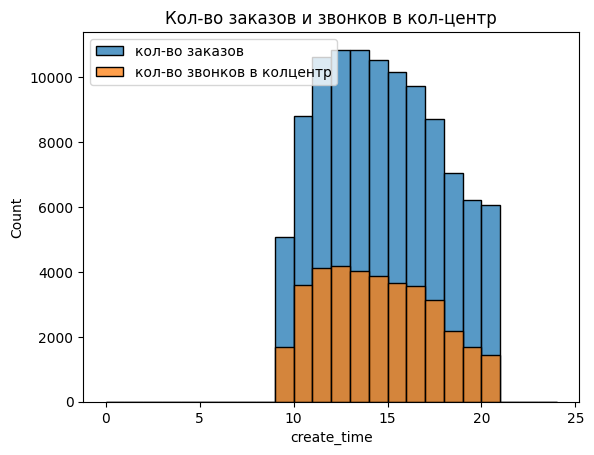

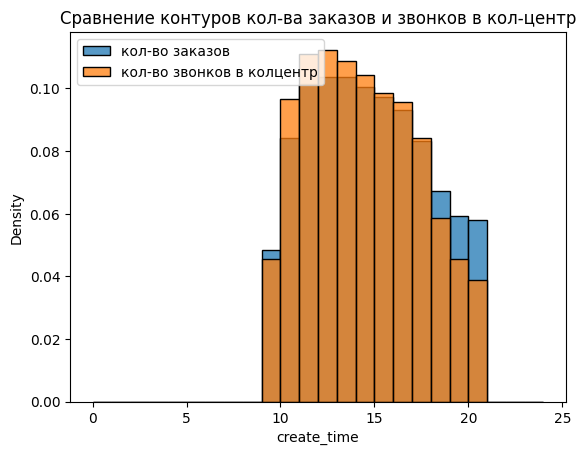

In [ ]:
sns.histplot(train.create_time.dt.hour, bins = 24, binrange = (0, 24), label = 'кол-во заказов' )
sns.histplot(train.query('is_callcenter == 1').create_time.dt.hour, bins = 24, binrange = (0, 24), label = 'кол-во звонков в колцентр')
plt.title('Кол-во заказов и звонков в кол-центр')
plt.legend()
plt.show()


sns.histplot(train.create_time.dt.hour, bins = 24, binrange = (0, 24), stat = 'density', label = 'кол-во заказов')
sns.histplot(train.query('is_callcenter == 1').create_time.dt.hour, bins = 24, binrange = (0, 24), stat = 'density', label = 'кол-во звонков в колцентр')
plt.title('Сравнение контуров кол-ва заказов и звонков в кол-центр')
plt.legend()
plt.show()


контуры не совпадают

In [ ]:
import numpy as np
train['order_created_at'] = np.select(
    [
        train['order_BEFORE_session'] == 1,
        train['order_DURING_session'] == 1,
        train['order_AFTER_session'] == 1
    ],
    [-1, 0, 1],
    default=np.nan
)

In [ ]:
train

,order_id,create_time,good_id,price,sessionkey_id,is_callcenter,date_time_min,date_time_max,ends_with_nan_sec,session_pages_cnt,sec_on_last_page,delta_time,total_pageview_duration_sec,total_pageview_duration > delta_time,order_BEFORE_session,order_DURING_session,order_AFTER_session,order_created_at
0,1269921,1975-12-26 09:30:08,9896348,753,123777004,1,1975-12-26 09:21:03.393,1975-12-26 09:21:03.393,True,1.0,NaN,0.000,0.0,False,False,False,True,1.0
1,1270034,1975-12-26 10:28:57,9896348,753,123781654,0,1975-12-26 09:50:26.857,1975-12-26 11:01:03.407,True,28.0,NaN,4236.550,3831.0,False,False,True,False,0.0
2,1268272,1975-12-25 11:24:28,9896348,753,123591002,1,1975-12-25 11:17:02.940,1975-12-25 11:23:12.517,True,7.0,NaN,369.577,370.0,True,False,False,True,1.0
3,1270544,1975-12-26 14:16:06,9896348,753,123832302,1,1975-12-26 13:57:51.157,1975-12-26 14:29:57.153,True,6.0,NaN,1925.996,1926.0,True,False,True,False,0.0
4,1270970,1975-12-26 18:21:47,9896348,753,123881603,0,1975-12-26 18:10:27.970,1975-12-26 18:17:54.257,False,6.0,9.0,446.287,94.0,False,False,False,True,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104590,1250981,1975-12-16 12:11:32,68657110,1497,121795335,1,1975-12-16 12:04:02.273,1975-12-16 12:56:06.990,True,9.0,NaN,3124.717,3109.0,False,False,True,False,0.0
104591,1173775,1975-11-08 11:29:50,60391507,1354,114277105,1,1975-11-07 23:37:34.260,1975-11-07 23:55:00.773,True,10.0,NaN,1046.513,610.0,False,False,False,True,1.0
104592,1180920,1975-11-12 09:14:35,66971400,1452,114972131,0,1975-11-12 08:37:30.500,1975-11-12 09:15:26.047,False,39.0,8.0,2275.547,1602.0,False,False,True,False,0.0
104593,1177882,1975-11-10 17:28:07,60391498,1433,114672813,1,1975-11-10 17:00:21.517,1975-11-10 17:23:02.973,True,9.0,NaN,1361.456,1361.0,False,False,False,True,1.0


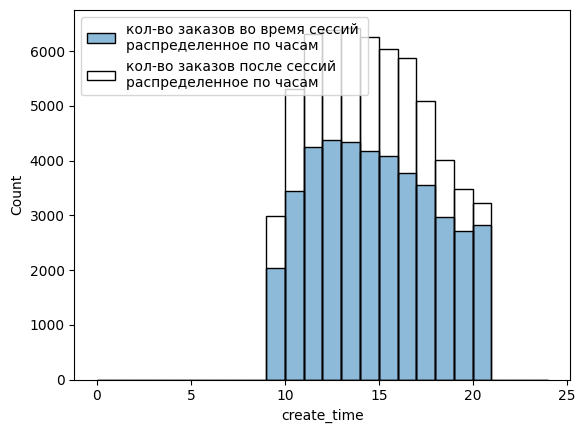

In [ ]:
sns.histplot(train.query('order_created_at == 0').create_time.dt.hour, bins = 24, binrange = (0, 24), alpha = 0.5, label = 'кол-во заказов во время сессий \nраспределенное по часам')
#plt.title('Кол-во заказов и звонков в кол-центр')
plt.legend()


sns.histplot(train.query('order_created_at == 1').create_time.dt.hour, bins = 24, binrange = (0, 24), alpha = 0, label = 'кол-во заказов после сессий \nраспределенное по часам')
#plt.title('Кол-во заказов и звонков в кол-центр')

plt.legend()
plt.show()

Т.к в тестовых данных и тренировочных видим столбцы "good_id", "price".

**Гипотеза: Попробуем найти взаимосвязь в тренировочных данных между good_id товара и звонками в колцентр** и затем применить их на тестовые данные

Посмотрим сколько звонков приходится на каждый товар с  его good_id, посчитаем их в "штуках" и в процентном соотношении, чтобы увидеть какая есть вероятность получить звонок по конкретному товару

In [ ]:
good_stats = (
    train
    .groupby('good_id')['is_callcenter']
    .agg(
        total='count',
        calls='sum',
        call_rate='mean'
    )
    .sort_values('calls', ascending=False)
)
good_stats

,total,calls,call_rate
good_id,,,
66921494,260,82,0.315385
25559462,118,57,0.483051
62408739,76,48,0.631579
61831405,91,48,0.527473
60089129,78,44,0.564103
...,...,...,...
10101745,5,0,0.000000
10097586,1,0,0.000000
10089692,3,0,0.000000


- сделали сортировку по calls
- применяем полученную зависимость к тестовым данным:

In [ ]:
test['call_rate'] = test['good_id'].map(good_stats['call_rate'])
test

,order_id,create_time,good_id,price,sessionkey_id,call_rate
0,1350922,1976-02-05 15:08:37,9896348,1143,132744630,0.410714
1,1354989,1976-02-07 15:26:00,69445048,1707,133161905,0.750000
2,1352637,1976-02-06 11:43:58,70607886,576,132792626,NaN
3,1350050,1976-02-05 11:26:19,61918401,436,132683062,NaN
4,1341733,1976-02-01 19:36:32,37964900,573,131789790,NaN
...,...,...,...,...,...,...
17191,1358397,1976-02-09 16:13:20,74484779,236,131980166,NaN
17192,1357968,1976-02-09 14:30:59,75277186,108,133527708,NaN
17193,1358835,1976-02-09 18:39:45,75382827,602,133585500,NaN
17194,1365692,1976-02-12 17:50:18,76012025,818,133876415,NaN


In [ ]:
test['good_id'].nunique()

12183

In [ ]:
test.query('call_rate.notna()')['good_id'].nunique()

4743

**Закрыли прогноз на 4743 значение из 12183**

**Посмотрим теперь на связь между временем создания заказа created_time и звонками в колцентр is_callcenter**

In [ ]:
create_time_stats = (
    train
    .groupby(train['create_time'].dt.hour)['is_callcenter']
    .agg(
        total='count',
        calls='sum',
        call_rate='mean'
    )
    .sort_index()
)
create_time_stats

,total,calls,call_rate
create_time,,,
9,5064,1688,0.333333
10,8809,3584,0.406857
11,10622,4122,0.388063
12,10839,4171,0.384814
13,10844,4034,0.372003
14,10516,3871,0.368106
15,10166,3652,0.359237
16,9733,3555,0.365252
17,8711,3122,0.358397


- получили вероятность получить звонок по часам
- применим теперь эти значения на тестовые данные, при этом заполним только "пустые" значения (которые до этого были NaN)

In [ ]:
test['call_rate'] = test['call_rate'].fillna(
    test['create_time'].dt.hour.map(create_time_stats['call_rate'])
)
test

,order_id,create_time,good_id,price,sessionkey_id,call_rate
0,1350922,1976-02-05 15:08:37,9896348,1143,132744630,0.410714
1,1354989,1976-02-07 15:26:00,69445048,1707,133161905,0.750000
2,1352637,1976-02-06 11:43:58,70607886,576,132792626,0.388063
3,1350050,1976-02-05 11:26:19,61918401,436,132683062,0.388063
4,1341733,1976-02-01 19:36:32,37964900,573,131789790,0.272288
...,...,...,...,...,...,...
17191,1358397,1976-02-09 16:13:20,74484779,236,131980166,0.365252
17192,1357968,1976-02-09 14:30:59,75277186,108,133527708,0.368106
17193,1358835,1976-02-09 18:39:45,75382827,602,133585500,0.309016
17194,1365692,1976-02-12 17:50:18,76012025,818,133876415,0.358397


оформим ответы в отдельнй дата фрейм prediction и сохраним его как csv, со столбцами: 'order_id', 'is_callcenter'

In [ ]:
prediction = pd.DataFrame({
    'order_id' : test['order_id'],
    'is_callcenter' : test['call_rate']
})
prediction

,order_id,is_callcenter
0,1350922,0.410714
1,1354989,0.750000
2,1352637,0.388063
3,1350050,0.388063
4,1341733,0.272288
...,...,...
17191,1358397,0.365252
17192,1357968,0.368106
17193,1358835,0.309016
17194,1365692,0.358397


In [ ]:
prediction.to_csv('prediction.csv', index=False)

In [ ]:
from google.colab import files

files.download('prediction.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
prediction.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17196 entries, 0 to 17195
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       17196 non-null  int64  
 1   is_callcenter  17196 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 268.8 KB


А теперь сделаем новый дата фрейм submission и далее сохраним его как csv, который будет содержать бинарный (0,1) результат для is_callcenter

In [ ]:
np.random.seed(42)

test['prediction'] = (
    np.random.rand(len(test)) < test['call_rate']
).astype(int)

submission = pd.DataFrame({
    'order_id': test['order_id'],
    'is_callcenter': test['prediction']
})

submission.to_csv('submission.csv', index=False)

In [ ]:
submission.head(5)

,order_id,is_callcenter
0,1350922,1
1,1354989,0
2,1352637,0
3,1350050,0
4,1341733,1


In [ ]:
from google.colab import files

files.download('submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

plt.subplot(1, 2, 1)
означает 1 строка, 2 графика, первый.